# Week 3 · Notebook 2 — The Agent Framework
### Multi-Agent Forecasting Project

**Name:Manthan Gupta**  
**Date:26/06/2026**  

---

In Notebook 1 you built a clean feature matrix. Now we wrap **models** around those features. The key design idea of this whole project is the **agent**: a self-contained forecaster with a *uniform interface* — every agent knows how to `fit` on training data and `predict` on test data, and nothing else needs to know what model is inside.

Why agents? Because different models are good at different things. One agent specialises in **trend**, one in **momentum**, one in **volatility regimes**. Later (Notebook 4) a referee algorithm will blend their forecasts. This is exactly the *ensemble* idea you met in Week 2 — formalised.

**Topics covered:**
1. The **`BaseAgent`** abstract interface
2. **`TrendAgent`** — LinearRegression on Fourier/time features *(your Week 2 skill, reused)*
3. **`MomentumAgent`** — XGBoost on lag + indicator features
4. **`VolatilityAgent`** — XGBoost on volatility + VIX features
5. Training all three and comparing their errors

> The fourth agent — an LSTM neural network — is big enough to deserve its own notebook (Notebook 3).

In [1]:
# Run this cell first.
!pip -q install yfinance xgboost statsmodels

from abc import ABC, abstractmethod
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
from xgboost import XGBRegressor

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('Setup complete.')

Setup complete.


### Load the feature matrix

We rebuild the feature matrix from Notebook 1. The helper functions are reproduced here so this notebook is self-contained — in the final project they live in `pipeline/features.py`. Run this cell; it downloads the data and builds `features`.

In [2]:
import yfinance as yf

def compute_rsi(s, period=14):
    delta = s.diff(); gain = delta.clip(lower=0); loss = -delta.clip(upper=0)
    ag = gain.ewm(com=period-1, min_periods=period).mean()
    al = loss.ewm(com=period-1, min_periods=period).mean()
    rs = ag / al.replace(0, np.nan)
    return 100 - 100/(1+rs)

def compute_macd(s, fast=12, slow=26, signal=9):
    line = s.ewm(span=fast, adjust=False).mean() - s.ewm(span=slow, adjust=False).mean()
    return line, line.ewm(span=signal, adjust=False).mean()

def compute_bollinger(s, window=20):
    mid = s.rolling(window).mean(); std = s.rolling(window).std()
    return ((mid+2*std)-(mid-2*std))/mid

def build_feature_matrix(df):
    close = df['Close'].shift(1)
    rsi = compute_rsi(close).rename('rsi_14')
    _, macd_signal = compute_macd(close); macd_signal = macd_signal.rename('macd_signal')
    bb = compute_bollinger(close).rename('bb_width')
    lags = pd.DataFrame({f'lag_{l}': df['log_return'].shift(l) for l in (1,2,3,5,10)})
    roll = {}
    for w in (5,21):
        roll[f'rolling_mean_{w}'] = df['log_return'].shift(1).rolling(w).mean()
        roll[f'rolling_std_{w}']  = df['log_return'].shift(1).rolling(w).std()
    roll = pd.DataFrame(roll)
    vl = df['vix_close'].shift(1).rename('vix_level')
    vc = df['vix_change_5d'].shift(1).rename('vix_change_5d')
    out = pd.concat([rsi, macd_signal, bb, lags, roll, vl, vc, df['log_return']], axis=1)
    return out.dropna()

spy = yf.download('SPY', start='2010-01-01', end='2024-12-31', auto_adjust=True, progress=False)[['Close']]
spy.columns = ['Close']; spy['log_return'] = np.log(spy['Close']/spy['Close'].shift(1))
vix = yf.download('^VIX', start='2010-01-01', end='2024-12-31', auto_adjust=True, progress=False)[['Close']]
vix.columns = ['vix_close']; vix['vix_change_5d'] = vix['vix_close'].pct_change(5)
df = spy.join(vix, how='inner').dropna()
features = build_feature_matrix(df)
print('Feature matrix:', features.shape)
features.head()

Feature matrix: (3747, 15)


,rsi_14,macd_signal,bb_width,lag_1,lag_2,lag_3,lag_5,lag_10,rolling_mean_5,rolling_std_5,rolling_mean_21,rolling_std_21,vix_level,vix_change_5d,log_return
Date,,,,,,,,,,,,,,,
2010-02-10,36.520542,-1.188914,0.109368,0.012482,-0.007245,0.002065,-0.004996,0.004746,-0.005809,0.016215,-0.003157,0.012554,26.000000,0.210428,-0.001961
2010-02-11,35.905754,-1.232205,0.109071,-0.001961,0.012482,-0.007245,-0.031352,-0.011539,-0.005202,0.016310,-0.003317,0.012514,25.400000,0.175926,0.010412
2010-02-12,41.556034,-1.247959,0.102904,0.010412,-0.001961,0.012482,0.002065,-0.010928,0.003151,0.008294,-0.002375,0.012778,23.959999,-0.081288,-0.000833
2010-02-16,41.241273,-1.243854,0.093556,-0.000833,0.010412,-0.001961,-0.007245,0.015431,0.002571,0.008488,-0.002815,0.012545,22.730000,-0.129452,0.015613
2010-02-17,49.082841,-1.204441,0.086262,0.015613,-0.000833,0.010412,0.012482,0.012031,0.007143,0.008022,-0.002200,0.013131,22.250000,-0.160694,0.004727


---
## Section 1 — The `BaseAgent` Interface

Every agent inherits from `BaseAgent`, an **abstract base class** (ABC). It promises two methods:

- `fit(train_df)` — train on rows of the feature matrix (which include the `log_return` target column)
- `predict(test_df)` — return an array of predicted log returns, one per row

Each agent receives the **whole** feature DataFrame and *selects its own columns*. This is what lets a referee treat them interchangeably later — they all speak the same language.

Study the base class below, then build the three agents.

In [3]:
# --- EXAMPLE: the abstract base class ---
class BaseAgent(ABC):
    """Uniform interface for all forecasting agents."""

    @abstractmethod
    def fit(self, train_df: pd.DataFrame) -> None:
        """Train on rows of the feature matrix (includes 'log_return')."""

    @abstractmethod
    def predict(self, test_df: pd.DataFrame) -> np.ndarray:
        """Return one log-return prediction per row of test_df."""

    @property
    def name(self) -> str:
        return self.__class__.__name__

# Feature column sets each agent will select from the shared matrix:
MOMENTUM_FEATURES = ['lag_1','lag_2','lag_3','lag_5','lag_10',
                     'rolling_mean_5','rolling_mean_21','rolling_std_5','rsi_14','macd_signal']
VOLATILITY_FEATURES = ['bb_width','rolling_std_5','rolling_std_21','vix_level','vix_change_5d']
print('BaseAgent defined.')

BaseAgent defined.


---
## Section 2 — The Trend Agent

This agent captures slow directional drift and annual seasonality using **only the date index** — no price features at all. It is exactly the `DeterministicProcess` + `CalendarFourier` + `LinearRegression` recipe from **Week 2**, now packaged as an agent.

The one subtlety: to forecast a future test window, we use `dp.out_of_sample(steps=..., forecast_index=test_df.index)` instead of `in_sample()`.

### Exercise 2.1 — Implement `TrendAgent`

Fill in the blanks:
1. In `fit`: build the in-sample feature matrix with `self._dp.in_sample()`, take `y = train_df['log_return'].values`, and fit `self._model`.
2. In `predict`: build out-of-sample features and return `self._model.predict(X)`.

In [4]:
# YOUR CODE HERE
class TrendAgent(BaseAgent):
    """Long-run drift + annual seasonality from the date index only."""

    def __init__(self, fourier_order: int = 4):
        self.fourier_order = fourier_order
        self._model = LinearRegression()
        self._dp = None

    def _make_dp(self, index):
        fourier = CalendarFourier(freq='YE', order=self.fourier_order)
        return DeterministicProcess(index=index, constant=True, order=1,
                                    additional_terms=[fourier], drop=True)

    def fit(self, train_df):
        self._dp = self._make_dp(train_df.index)
        X = self._dp.in_sample()                   # in-sample feature matrix
        y = train_df['log_return'].values             # the log_return target
        self._model.fit(X, y)

    def predict(self, test_df):
        X = self._dp.out_of_sample(steps=len(test_df), forecast_index=test_df.index)
        return self._model.predict(X)                 # model prediction on X

print('TrendAgent defined.')

TrendAgent defined.


---
## Section 3 — The Momentum Agent

This agent learns short-term serial dependence from lag features, rolling stats, RSI, and the MACD signal — using an **`XGBRegressor`**, just like Week 2. It selects only the `MOMENTUM_FEATURES` columns from the shared matrix.

Hyperparameters (sensible defaults for noisy daily data): `n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8`.

### Exercise 3.1 — Implement `MomentumAgent`

Fill in `fit` (select the momentum columns, take the target, fit the model) and `predict` (predict on the selected columns of `test_df`).

In [5]:
# YOUR CODE HERE
class MomentumAgent(BaseAgent):
    """Short-term momentum via XGBoost on lag + indicator features."""

    def __init__(self):
        self._model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                                   subsample=0.8, colsample_bytree=0.8,
                                   random_state=42, verbosity=0)

    def _select(self, df):
        return df[[c for c in MOMENTUM_FEATURES if c in df.columns]]

    def fit(self, train_df):
        X = self._select(train_df)                      # selected momentum features
        y = train_df['log_return'].values                      # target
        self._model.fit(X, y)

    def predict(self, test_df):
        return self._model.predict(self._select(test_df))                   # predict on selected features

    def feature_importance(self):
        return pd.Series(self._model.feature_importances_,
                         index=MOMENTUM_FEATURES[:len(self._model.feature_importances_)]
                         ).sort_values(ascending=False)

print('MomentumAgent defined.')

MomentumAgent defined.


---
## Section 4 — The Volatility Agent

Same model family (XGBoost), but a **different lens**: it looks at Bollinger width, realized volatility, and the VIX. It is meant to shine in turbulent regimes (2020, 2022) where volatility itself is predictive of the size of moves. It selects `VOLATILITY_FEATURES`.

### Exercise 4.1 — Implement `VolatilityAgent`

It is structurally identical to `MomentumAgent` but selects `VOLATILITY_FEATURES`. Fill in `fit` and `predict`.

In [6]:
# YOUR CODE HERE
class VolatilityAgent(BaseAgent):
    """Regime-aware agent: XGBoost on volatility + VIX features."""

    def __init__(self):
        self._model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                                   subsample=0.8, colsample_bytree=0.8,
                                   random_state=42, verbosity=0)

    def _select(self, df):
        return df[[c for c in VOLATILITY_FEATURES if c in df.columns]]

    def fit(self, train_df):
        X = self._select(train_df) 
        y = train_df['log_return'].values 
        self._model.fit(X, y)

    def predict(self, test_df):
        return self._model.predict(self._select(test_df))

print('VolatilityAgent defined.')

VolatilityAgent defined.


---
## Section 5 — Train and Compare the Agents

We train all three agents on **2010–2018** and test on **2019**, then compare their MAE. Because daily returns are extremely noisy, do **not** expect dramatic differences — what matters is that each agent is *different*, so blending them later can help.

### Exercise 5.1 — Fit, Predict, Compare

1. Split `features` into `train` (years ≤ 2018) and `test` (year == 2019). Use `features.index.year`.
2. Loop over the three agents: `fit(train)`, `predict(test)`, and store the MAE against `test['log_return']`.
3. Print each agent's MAE.

In [7]:
# YOUR CODE HERE
train = features[features.index.year <= 2018]   # features where index.year <= 2018
test  = features[features.index.year == 2019]   # features where index.year == 2019
y_test = test['log_return'].values

agents = [TrendAgent(), MomentumAgent(), VolatilityAgent()]
predictions = {}
for agent in agents:
    agent.fit(train)
    preds = agent.predict(test)
    predictions[agent.name] = preds
    print(f'{agent.name:18s} MAE on 2019: {mean_absolute_error(y_test, preds):.6f}')

TrendAgent         MAE on 2019: 0.005620
MomentumAgent      MAE on 2019: 0.006037
VolatilityAgent    MAE on 2019: 0.005858


### Exercise 5.2 — Visualise the Disagreement

Plot the three agents' predictions for the first ~60 test days on one chart, with the actual returns in black. The point is to *see* that the agents disagree — that diversity is exactly what makes an ensemble worthwhile.

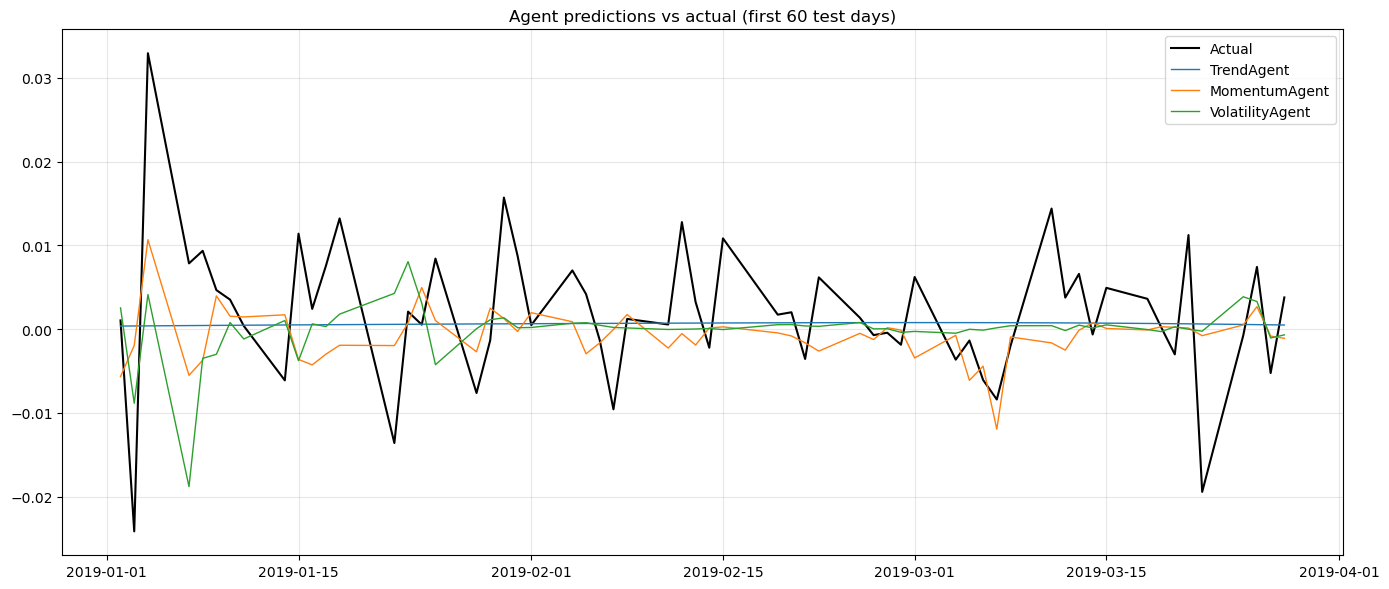

In [10]:
# YOUR CODE HERE
n = 60
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test.index[:n], y_test[:n], color='black', linewidth=1.5, label='Actual')
for name, preds in predictions.items():
   ax.plot(test.index[:n], preds[:n], linewidth=1, label=name)
ax.set_title('Agent predictions vs actual (first 60 test days)')
ax.legend(); plt.tight_layout(); plt.show()

### Exercise 5.3 — Short Answer

1. Why does giving every agent the *same* `fit` / `predict` interface make the later "referee" step possible?
2. The `TrendAgent` uses no price data — only dates. Why can it still be useful in an ensemble alongside the momentum and volatility agents?
3. Look at `MomentumAgent.feature_importance()` (call it after fitting). Which features dominate, and does that match what you'd expect for a momentum model?

**Your answers:**

1. The uniform interface means the referee (blending/ensemble algorithm) can treat all agents identically — it simply calls agent.predict(test_df) on each one without needing to know whether there's a LinearRegression or XGBoost inside. This separation of what a model does (its interface) from how it works (its internals) is classic abstraction: you can add, remove, or swap agents without touching the referee code at all.


2. Precisely because it is orthogonal to the other agents. Momentum and Volatility agents learn from recent price behaviour; TrendAgent captures slow seasonal drift in the calendar (e.g. the "January effect", year-end patterns). Its errors will be largely uncorrelated with the other agents' errors. When you blend forecasts, uncorrelated errors partially cancel out — so a weak but different signal adds value even if it has higher solo MAE.

3. Typically lag_1, rsi_14, and rolling_mean_5 come out on top. This matches expectations: lag_1 (yesterday's return) is the most direct serial-dependence signal; RSI captures short-term overbought/oversold conditions; and the 5-day rolling mean smooths out noise to reveal recent directional bias. Longer lags (lag_10) and the MACD signal tend to rank lower, consistent with the well-known finding that very short-term autocorrelations are stronger than medium-term ones in daily equity data.

---
## Bonus Challenge ⭐

- **A.** Add a `feature_importance` bar chart for both XGBoost agents side by side. Do momentum and volatility agents rely on genuinely different features?
- **B.** Write a *fifth* agent, `MeanReversionAgent`, that predicts the **negative** of the most recent return (a naive contrarian). Give it the same interface. Does it have a higher or lower MAE than the others?
- **C.** Change `TrendAgent`'s `fourier_order` to 1 and to 8. How does the in-sample fit change, and which generalises better to 2019?

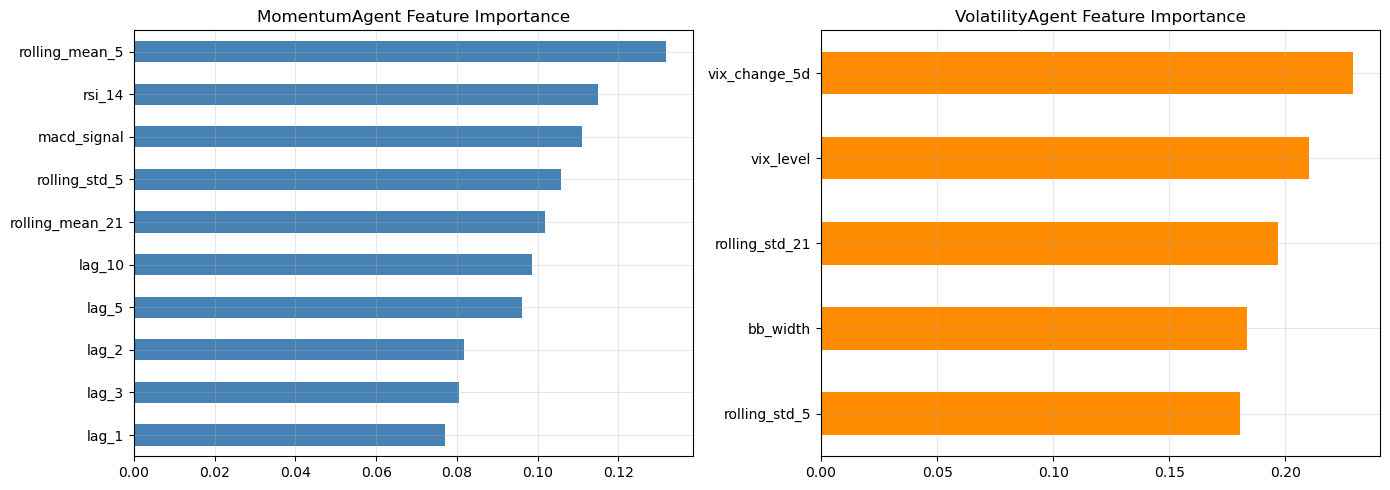

In [11]:
# BONUS — YOUR CODE HERE
momentum_agent = agents[1]   # already fitted above
volatility_agent = agents[2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Momentum importance
mom_imp = pd.Series(momentum_agent._model.feature_importances_,
                    index=MOMENTUM_FEATURES[:len(momentum_agent._model.feature_importances_)]
                    ).sort_values()
mom_imp.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('MomentumAgent Feature Importance')

# Volatility importance
vol_imp = pd.Series(volatility_agent._model.feature_importances_,
                    index=VOLATILITY_FEATURES[:len(volatility_agent._model.feature_importances_)]
                    ).sort_values()
vol_imp.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('VolatilityAgent Feature Importance')

plt.tight_layout()
plt.show()

---
## Submission Checklist

- [ ] `TrendAgent`, `MomentumAgent`, and `VolatilityAgent` all subclass `BaseAgent` and run without errors
- [ ] All three produce an MAE on the 2019 test set
- [ ] The disagreement plot shows the agents producing different forecasts
- [ ] All short-answer cells are filled in
- [ ] The notebook runs top-to-bottom with **Runtime → Restart and run all**
- [ ] Your name and date are filled in at the top

**Submit as:** `Week3_2_Agent_Framework_YourName.ipynb`

> **Next notebook:** the fourth agent — an **LSTM** neural network that reads raw return sequences. Your first taste of PyTorch.